# Compare Laptop Prices with T-Tests per Cluster

In [17]:
import pandas as pd
from scipy.stats import ttest_ind

# Load your clustered dataset
df = pd.read_csv("../Step 2 - Normalize specs and identify equivalent laptops/clustered_laptops_1.csv", encoding="utf-8-sig")

# Ensure required columns exist
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Cluster"] = pd.to_numeric(df["Cluster"], errors="coerce")

# Group by clusters and compare prices between retailers
clusters = df["Cluster"].unique()
ttest_results = []

for cluster_id in sorted(clusters):
    cluster_data = df[df["Cluster"] == cluster_id]
    
    elgiganten_prices = cluster_data[cluster_data["Retailer"] == "Elgiganten"]["Price"]
    komplett_prices = cluster_data[cluster_data["Retailer"] == "Komplett"]["Price"]

    # Only perform t-test if both groups have at least 2 laptops
    if len(elgiganten_prices) >= 2 and len(komplett_prices) >= 2:
        t_stat, p_value = ttest_ind(elgiganten_prices, komplett_prices, equal_var=False)
    else:
        t_stat, p_value = None, None

    ttest_results.append({
        "Cluster": cluster_id,
        "Elgiganten_N": len(elgiganten_prices),
        "Komplett_N": len(komplett_prices),
        "Elgiganten_Mean": elgiganten_prices.mean() if not elgiganten_prices.empty else None,
        "Komplett_Mean": komplett_prices.mean() if not komplett_prices.empty else None,
        "T-Statistic": t_stat,
        "P-Value": p_value,
        "Significant": p_value is not None and p_value < 0.05
    })

# Convert to DataFrame
ttest_df = pd.DataFrame(ttest_results)

# Save results to CSV
ttest_df.to_csv("ttest_results_by_cluster_1.csv", index=False, encoding="utf-8-sig")

# Show summary
print("T-tests done! Results saved to 'ttest_results_by_cluster_1.csv'")
print(ttest_df)

T-tests done! Results saved to 'ttest_results_by_cluster_1.csv'
   Cluster  Elgiganten_N  Komplett_N  Elgiganten_Mean  Komplett_Mean  \
0      1.0            38          77     23961.131579   25193.324675   
1      3.0            35          20     12575.857143   14196.150000   
2      6.0            57          38      7067.280702    6971.684211   
3      7.0             4          58     38242.250000   40304.534483   
4      8.0            48          70     10482.354167   11016.957143   
5      9.0            60          89     17599.266667   15158.258427   

   T-Statistic   P-Value  Significant  
0    -1.359848  0.177822        False  
1    -0.844215  0.404349        False  
2     0.201868  0.840461        False  
3    -1.022638  0.342743        False  
4    -0.949422  0.344397        False  
5     4.781538  0.000004         True  


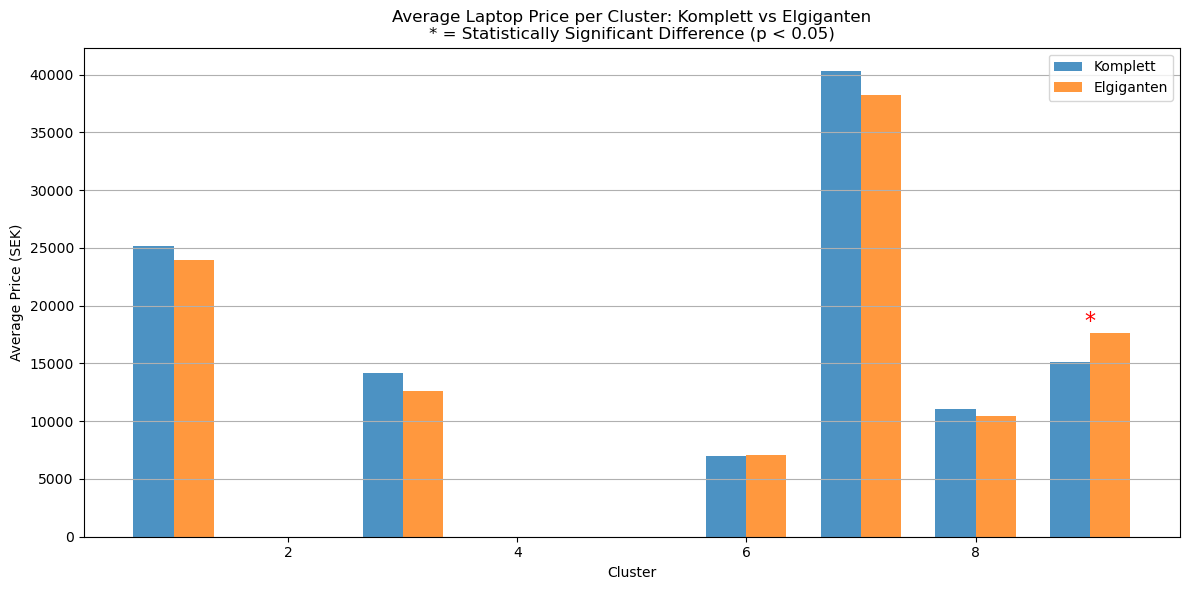

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load t-test results
ttest_df = pd.read_csv("ttest_results_by_cluster_1.csv", encoding="utf-8-sig")

# Filter out clusters where one of the means is missing
plot_df = ttest_df.dropna(subset=["Elgiganten_Mean", "Komplett_Mean"])
plot_df = plot_df.sort_values("Cluster")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = plot_df["Cluster"]
bar_width = 0.35

# Swap bar order: Komplett on the left, Elgiganten on the right
ax.bar(x - bar_width/2, plot_df["Komplett_Mean"], width=bar_width, label="Komplett", alpha=0.8)
ax.bar(x + bar_width/2, plot_df["Elgiganten_Mean"], width=bar_width, label="Elgiganten", alpha=0.8)

# Add asterisk for significant differences
for i, row in plot_df.iterrows():
    max_y = max(row["Elgiganten_Mean"], row["Komplett_Mean"])
    if row["Significant"]:
        ax.text(row["Cluster"], max_y + 500, "*", ha='center', fontsize=16, color='red')

# Labels and title (updated perspective)
ax.set_xlabel("Cluster")
ax.set_ylabel("Average Price (SEK)")
ax.set_title("Average Laptop Price per Cluster: Komplett vs Elgiganten\n* = Statistically Significant Difference (p < 0.05)")
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

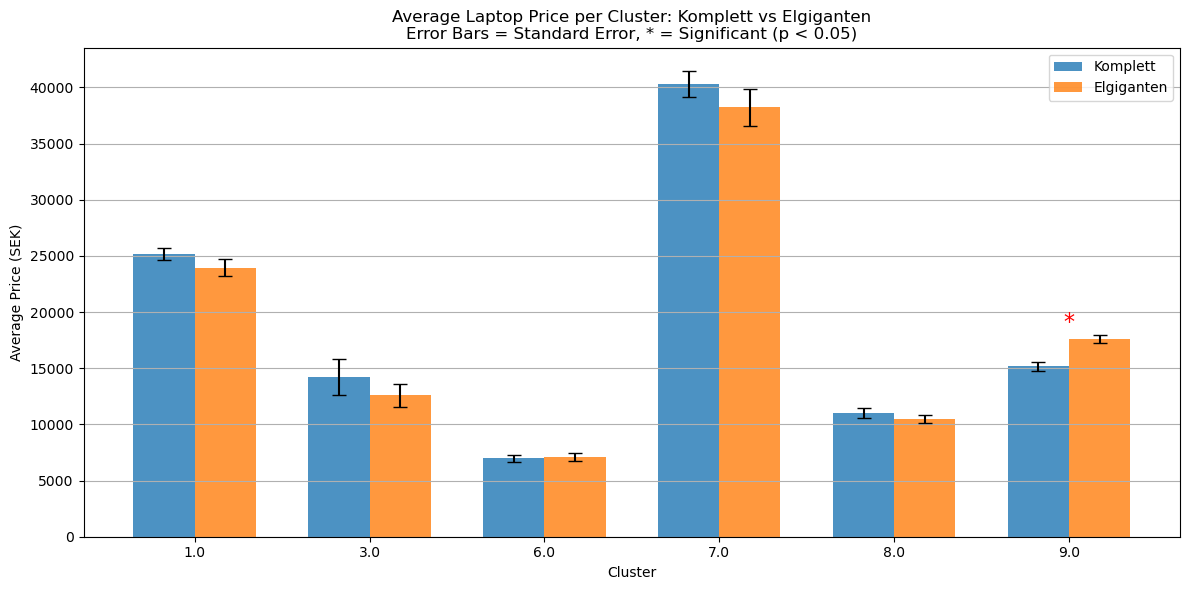

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate standard error
def get_error(series):
    return series.std(ddof=1) / np.sqrt(len(series)) if len(series) > 1 else 0

# Prepare error bars
errors_ko = []
errors_eg = []

for cluster_id in plot_df["Cluster"]:
    cluster_data = df[df["Cluster"] == cluster_id]
    ko_prices = cluster_data[cluster_data["Retailer"] == "Komplett"]["Price"]
    eg_prices = cluster_data[cluster_data["Retailer"] == "Elgiganten"]["Price"]
    errors_ko.append(get_error(ko_prices))
    errors_eg.append(get_error(eg_prices))

# Plot with error bars
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_df))
bar_width = 0.35

# Komplett bar first (left), Elgiganten second (right)
ax.bar(x - bar_width/2, plot_df["Komplett_Mean"], width=bar_width,
       label="Komplett", yerr=errors_ko, capsize=5, alpha=0.8)
ax.bar(x + bar_width/2, plot_df["Elgiganten_Mean"], width=bar_width,
       label="Elgiganten", yerr=errors_eg, capsize=5, alpha=0.8)

# Asterisk for statistically significant difference
for i, row in plot_df.iterrows():
    if row["Significant"]:
        max_y = max(row["Komplett_Mean"], row["Elgiganten_Mean"]) + max(errors_ko[i], errors_eg[i])
        ax.text(i, max_y + 500, "*", ha='center', fontsize=16, color='red')

# Labels and formatting
ax.set_xlabel("Cluster")
ax.set_ylabel("Average Price (SEK)")
ax.set_title("Average Laptop Price per Cluster: Komplett vs Elgiganten\nError Bars = Standard Error, * = Significant (p < 0.05)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Cluster"])
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

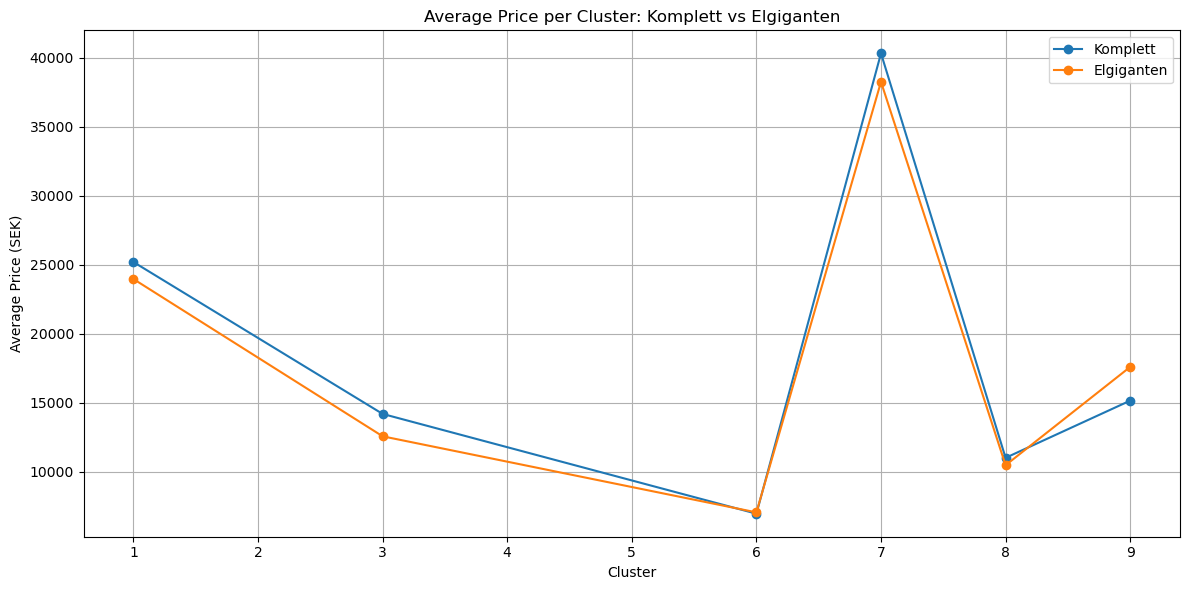

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(plot_df["Cluster"], plot_df["Komplett_Mean"], marker='o', label="Komplett")
plt.plot(plot_df["Cluster"], plot_df["Elgiganten_Mean"], marker='o', label="Elgiganten")
plt.title("Average Price per Cluster: Komplett vs Elgiganten")
plt.xlabel("Cluster")
plt.ylabel("Average Price (SEK)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()